In [1]:
import warnings
warnings.filterwarnings("ignore", module="pydantic")  

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold

try:
    import rasterio
except ModuleNotFoundError:
    !pip -q install rasterio
    import rasterio

from rasterio.errors import NotGeoreferencedWarning
warnings.filterwarnings("ignore", category=NotGeoreferencedWarning)

try:
    import timm
except ModuleNotFoundError:
    !pip -q install timm
    import timm

# reproducibility package
SEED = 42

def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

set_all_seeds(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 16.7 MB/s eta 0:00:0000:0100:01m
Device: cuda


**I got the data [here](https://www.kaggle.com/code/yaroslav53/bvs-ai-agri-2026-dataoverview-and-eda)** 

In [2]:
train_df = pd.read_csv('/kaggle/input/d/yaroslav53/bvs-train/train_df (1).csv')
val_df = pd.read_csv('//kaggle/input/d/yaroslav53/bvs-val/val_df (1).csv')

# list of objects whose pixels are zero
id_empty_objects_train = ['Other_hyper_26', 'Other_hyper_64', 'Other_hyper_113', 'Other_hyper_163', 'Other_hyper_174',
                          'Health_hyper_34', 'Health_hyper_167', 'Health_hyper_38', 'Other_hyper_50', 'Health_hyper_67',
                          'Other_hyper_160', 'Other_hyper_149', 'Other_hyper_31', 'Health_hyper_23', 'Other_hyper_102',
                          'Health_hyper_153', 'Health_hyper_26', 'Other_hyper_122', 'Other_hyper_155', 'Health_hyper_12',
                          'Health_hyper_76', 'Other_hyper_121', 'Other_hyper_22']
id_empty_objects_val =   ['val_5adcdc2e', 'val_6b6509fd', 'val_ceaa5449', 'val_5a361ff8', 'val_6cef0158', 'val_8e35e5d5',
                          'val_147643a2', 'val_d768878f', 'val_05cee914', 'val_f1a4afff', 'val_da9148e1']


train_df

,Id,Category,rgb_path,ms_path,hs_path
0,Health_hyper_1,Health,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...
1,Health_hyper_10,Health,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...
2,Health_hyper_100,Health,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...
3,Health_hyper_101,Health,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...
4,Health_hyper_102,Health,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...
...,...,...,...,...,...
595,Rust_hyper_95,Rust,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...
596,Rust_hyper_96,Rust,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...
597,Rust_hyper_97,Rust,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...
598,Rust_hyper_98,Rust,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...,/kaggle/input/beyond-visible-spectrum-ai-for-a...


# Dataset/DataLoader

In [3]:
CLASSES = ["Health", "Rust", "Other"]
cat2idx = {c: i for i, c in enumerate(CLASSES)}
idx2cat = {i: c for c, i in cat2idx.items()}

print(cat2idx, idx2cat)

{'Health': 0, 'Rust': 1, 'Other': 2} {0: 'Health', 1: 'Rust', 2: 'Other'}


In [36]:
# remove constants
train_df = train_df[~train_df["Id"].isin(id_empty_objects_train)].reset_index(drop=True)
train_df.shape

(577, 5)

*Multispectral and hyperspectral images store raw sensor measurements with higher bit depth rather than visual color intensities. Therefore, we apply per-sample min–max normalization to make the input scale-invariant and robust to illumination differences.*

- RGB global max: 255.0
- MS global max: 11406.0
- HS global max: 65535.0

# MS

In [37]:
ms_train_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.MultiplicativeNoise(
        multiplier=(0.97, 1.03),
        per_channel=False,
        p=0.15
    ),
], p=1.0)

ms_val_tf = A.Compose([], p=1.0)

In [38]:
def minmax_norm(x: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """per-sample normalization"""
    # x: (C,H,W) float32
    x_min = x.min()
    x_max = x.max()
    if (x_max - x_min) < eps:
        return np.zeros_like(x, dtype=np.float32)
    return (x - x_min) / (x_max - x_min)

pixel_minmax_tf = minmax_norm

In [39]:
class WheatMSDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        is_train: bool = True,
        pixel_tf=None,        
        aug_tf=None,            
        check_shape: bool = False
    ):
        df = df.reset_index(drop=True)
        self.is_train = is_train
        self.pixel_tf = pixel_tf
        self.aug_tf = aug_tf
        self.check_shape = check_shape

        self.ms_paths = df["ms_path"].astype(str).tolist()
        self.ids = df["Id"].astype(str).tolist()

        if is_train:
            self.y = df["Category"].map(cat2idx).to_numpy(np.int64)

    def __len__(self):
        return len(self.ms_paths)

    def _read_ms(self, path) -> np.ndarray:
        with rasterio.open(path) as src:
            x = src.read().astype(np.float32)  # (5,64,64) CHW
        return x

    def __getitem__(self, idx):
        ms = self._read_ms(self.ms_paths[idx])  # (C,H,W)

        if self.check_shape and ms.shape != (5, 64, 64):
            raise ValueError(f"Unexpected MS shape {ms.shape} for {self.ms_paths[idx]}")

        # Albumentations is awaiting HWC
        if self.aug_tf is not None:
            ms_hwc = np.transpose(ms, (1, 2, 0))                 # (H,W,C)
            ms_hwc = self.aug_tf(image=ms_hwc)["image"]          # (H,W,C)
            ms = np.transpose(ms_hwc, (2, 0, 1)).astype(np.float32)  # (C,H,W)

        # normalization of pixels 
        if self.pixel_tf is not None:
            ms = self.pixel_tf(ms)

        x = torch.from_numpy(ms)  # float32 CHW

        if self.is_train:
            y = torch.tensor(self.y[idx], dtype=torch.long)
            return x, y, self.ids[idx]
        else:
            return x, self.ids[idx]

In [40]:
class MSStemConvNeXt(nn.Module):
    def __init__(self, backbone_name="convnext_tiny", num_classes=3, drop=0.1, stem_width=16):
        super().__init__()

        # Slightly stronger spectral stem
        self.stem = nn.Sequential(
            nn.Conv2d(5, stem_width, kernel_size=1, bias=False),
            nn.BatchNorm2d(stem_width),
            nn.GELU(),
            nn.Conv2d(stem_width, 3, kernel_size=1, bias=False),
            nn.BatchNorm2d(3),
        )

        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)
        feat_dim = self.backbone.num_features

        hidden = feat_dim // 2
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(drop),
            nn.Linear(feat_dim, hidden),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        feats = self.backbone(x)
        return self.head(feats)

In [44]:
# configs
BATCH_SIZE = 64
NUM_CLASSES = len(CLASSES)
N_FOLDS = 5
EPOCHS = 20
lr_backbone = 1e-4
lr_head = 3e-4
WEIGHT_DECAY = 1e-2
BACKBONE = "convnext_tiny"

use_amp = False    #torch.cuda.is_available()
pin = torch.cuda.is_available()

train_df_ms = train_df.copy().reset_index(drop=True)

# OOF containers
oof_logits_ms = np.zeros((len(train_df_ms), NUM_CLASSES), dtype=np.float32)
oof_true   = train_df_ms["Category"].map(cat2idx).values.astype(np.int64)

# Store model weights per fold
fold_states_ms = []
fold_best_acc = []

In [42]:
def seed_worker(worker_id):
    worker_seed = (SEED + worker_id) % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

def make_loaders(
    df_tr, df_va,
    batch_size=BATCH_SIZE,
    pixel_tf=None,
    aug_tf_train=None,
    aug_tf_val=None,
    check_shape=False
):
    tr_ds = WheatMSDataset(df_tr, is_train=True, pixel_tf=pixel_tf, aug_tf=aug_tf_train, check_shape=check_shape)
    va_ds = WheatMSDataset(df_va, is_train=True, pixel_tf=pixel_tf, aug_tf=aug_tf_val,   check_shape=check_shape)

    g = torch.Generator()
    g.manual_seed(SEED)

    tr_loader = DataLoader(
        tr_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=3,
        pin_memory=True,
        persistent_workers=False,
        prefetch_factor=2,
        generator=g,
        worker_init_fn=seed_worker
    )
    va_loader = DataLoader(
        va_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=3,
        pin_memory=True,
        persistent_workers=False,
        prefetch_factor=2,
        worker_init_fn=seed_worker,
        generator=g
    )
    return tr_loader, va_loader

@torch.no_grad()
def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for xb, yb, _ in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=use_amp):
            logits = model(xb)
            loss = criterion(logits, yb)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(1) == yb).sum().item()
        total += bs

    return total_loss / total, total_correct / total

@torch.no_grad()
def validate_one_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    for xb, yb, _ in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        bs = xb.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(1) == yb).sum().item()
        total += bs

    return total_loss / total, total_correct / total

@torch.no_grad()
def predict_logits(model, loader):
    model.eval()
    all_logits = []

    for xb, yb, _ in loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        all_logits.append(logits.detach().cpu().numpy())

    return np.concatenate(all_logits, axis=0)



===== FOLD 1 / 5 | train=461 valid=116 =====
Epoch 01/20 | train loss 1.0213 acc 0.4924 | valid loss 1.1723 acc 0.2931 | best accuracy 0.2931 | patience 0/7
lrs [2.98e-04, 2.98e-04]
Epoch 02/20 | train loss 0.9234 acc 0.5380 | valid loss 1.0835 acc 0.4397 | best accuracy 0.4397 | patience 0/7
lrs [2.93e-04, 2.93e-04]
Unfroze backbone at epoch 3. Rebuilt optimizer/scheduler (remaining=18).
Epoch 03/20 | train loss 1.0380 acc 0.4816 | valid loss 1.1631 acc 0.3362 | best accuracy 0.4397 | patience 1/7
lrs [9.92e-05, 2.98e-04, 2.98e-04]
Epoch 05/20 | train loss 0.9123 acc 0.5271 | valid loss 1.0668 acc 0.3621 | best accuracy 0.4397 | patience 3/7
lrs [9.33e-05, 2.80e-04, 2.80e-04]
Epoch 10/20 | train loss 0.8235 acc 0.5683 | valid loss 0.7679 acc 0.6293 | best accuracy 0.6466 | patience 1/7
lrs [5.87e-05, 1.76e-04, 1.76e-04]
Epoch 15/20 | train loss 0.7895 acc 0.6052 | valid loss 0.7381 acc 0.6466 | best accuracy 0.6466 | patience 6/7
lrs [1.79e-05, 5.36e-05, 5.36e-05]
Epoch 20/20 | train

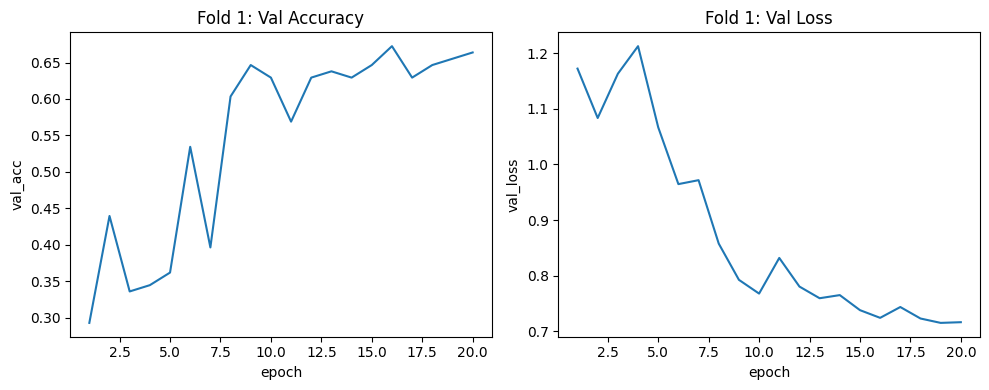


===== FOLD 2 / 5 | train=461 valid=116 =====
Epoch 01/20 | train loss 1.0084 acc 0.4599 | valid loss 1.0852 acc 0.3276 | best accuracy 0.3276 | patience 0/7
lrs [2.98e-04, 2.98e-04]
Epoch 02/20 | train loss 0.9145 acc 0.5510 | valid loss 1.1289 acc 0.3621 | best accuracy 0.3621 | patience 0/7
lrs [2.93e-04, 2.93e-04]
Unfroze backbone at epoch 3. Rebuilt optimizer/scheduler (remaining=18).
Epoch 03/20 | train loss 0.9980 acc 0.4685 | valid loss 1.1680 acc 0.4224 | best accuracy 0.4224 | patience 0/7
lrs [9.92e-05, 2.98e-04, 2.98e-04]
Epoch 05/20 | train loss 0.8858 acc 0.5510 | valid loss 1.0435 acc 0.3707 | best accuracy 0.4741 | patience 1/7
lrs [9.33e-05, 2.80e-04, 2.80e-04]
Epoch 10/20 | train loss 0.8170 acc 0.5401 | valid loss 0.7274 acc 0.6897 | best accuracy 0.6897 | patience 2/7
lrs [5.87e-05, 1.76e-04, 1.76e-04]
Epoch 15/20 | train loss 0.7149 acc 0.6443 | valid loss 0.6374 acc 0.7155 | best accuracy 0.7414 | patience 1/7
lrs [1.79e-05, 5.36e-05, 5.36e-05]
Epoch 20/20 | train

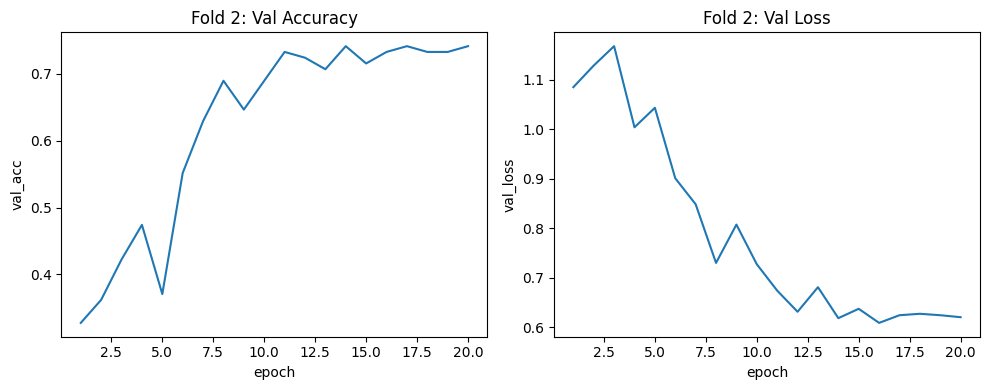


===== FOLD 3 / 5 | train=462 valid=115 =====
Epoch 01/20 | train loss 1.0378 acc 0.4091 | valid loss 1.0091 acc 0.4609 | best accuracy 0.4609 | patience 0/7
lrs [2.98e-04, 2.98e-04]
Epoch 02/20 | train loss 0.9378 acc 0.5411 | valid loss 0.9941 acc 0.5130 | best accuracy 0.5130 | patience 0/7
lrs [2.93e-04, 2.93e-04]
Unfroze backbone at epoch 3. Rebuilt optimizer/scheduler (remaining=18).
Epoch 03/20 | train loss 1.1520 acc 0.4091 | valid loss 1.1382 acc 0.4174 | best accuracy 0.5130 | patience 1/7
lrs [9.92e-05, 2.98e-04, 2.98e-04]
Epoch 05/20 | train loss 0.8765 acc 0.5498 | valid loss 0.9689 acc 0.5130 | best accuracy 0.5130 | patience 3/7
lrs [9.33e-05, 2.80e-04, 2.80e-04]
Epoch 10/20 | train loss 0.8235 acc 0.5563 | valid loss 0.7644 acc 0.6087 | best accuracy 0.6087 | patience 2/7
lrs [5.87e-05, 1.76e-04, 1.76e-04]
Epoch 15/20 | train loss 0.7925 acc 0.6082 | valid loss 0.7599 acc 0.6348 | best accuracy 0.6522 | patience 1/7
lrs [1.79e-05, 5.36e-05, 5.36e-05]
Epoch 20/20 | train

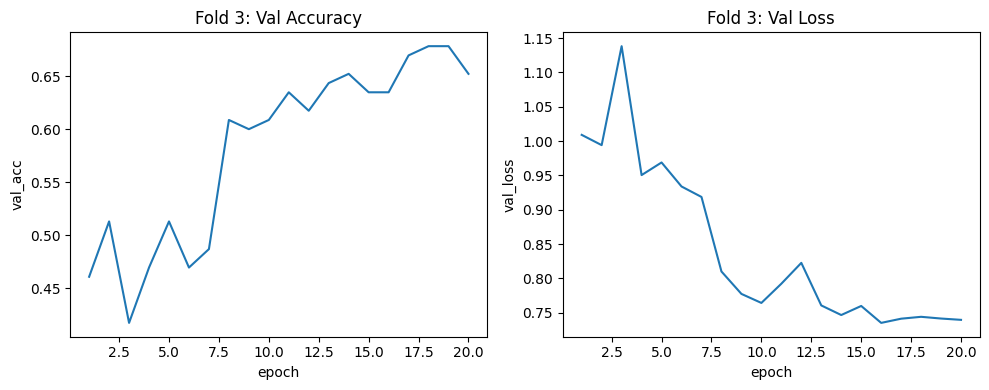


===== FOLD 4 / 5 | train=462 valid=115 =====
Epoch 01/20 | train loss 1.0065 acc 0.4762 | valid loss 1.0248 acc 0.4435 | best accuracy 0.4435 | patience 0/7
lrs [2.98e-04, 2.98e-04]
Epoch 02/20 | train loss 0.9040 acc 0.5433 | valid loss 0.9824 acc 0.4696 | best accuracy 0.4696 | patience 0/7
lrs [2.93e-04, 2.93e-04]
Unfroze backbone at epoch 3. Rebuilt optimizer/scheduler (remaining=18).
Epoch 03/20 | train loss 1.0633 acc 0.5065 | valid loss 1.1496 acc 0.3217 | best accuracy 0.4696 | patience 1/7
lrs [9.92e-05, 2.98e-04, 2.98e-04]
Epoch 05/20 | train loss 0.8640 acc 0.5303 | valid loss 1.0408 acc 0.4435 | best accuracy 0.4696 | patience 3/7
lrs [9.33e-05, 2.80e-04, 2.80e-04]
Epoch 10/20 | train loss 0.7222 acc 0.6537 | valid loss 0.7897 acc 0.6870 | best accuracy 0.6957 | patience 2/7
lrs [5.87e-05, 1.76e-04, 1.76e-04]
Epoch 15/20 | train loss 0.6671 acc 0.6753 | valid loss 0.7797 acc 0.6609 | best accuracy 0.6957 | patience 7/7
lrs [1.79e-05, 5.36e-05, 5.36e-05]
Early stopping on e

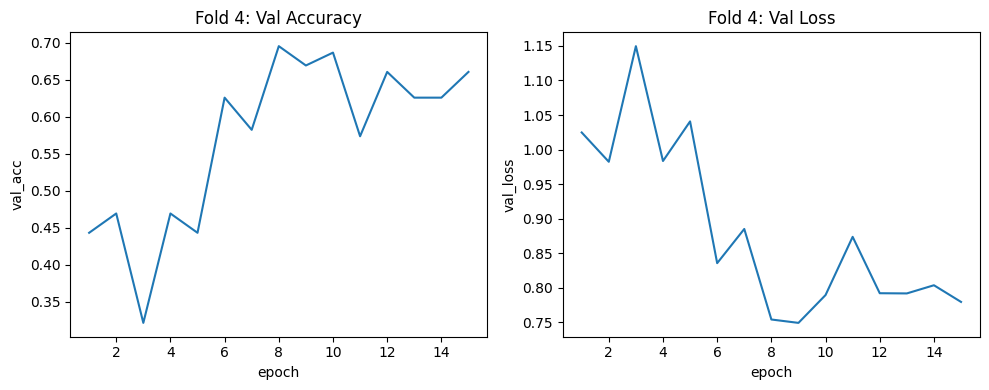


===== FOLD 5 / 5 | train=462 valid=115 =====
Epoch 01/20 | train loss 1.0299 acc 0.4329 | valid loss 1.0835 acc 0.3913 | best accuracy 0.3913 | patience 0/7
lrs [2.98e-04, 2.98e-04]
Epoch 02/20 | train loss 0.9383 acc 0.5108 | valid loss 1.1127 acc 0.3913 | best accuracy 0.3913 | patience 1/7
lrs [2.93e-04, 2.93e-04]
Unfroze backbone at epoch 3. Rebuilt optimizer/scheduler (remaining=18).
Epoch 03/20 | train loss 0.9800 acc 0.4870 | valid loss 1.1702 acc 0.3913 | best accuracy 0.3913 | patience 2/7
lrs [9.92e-05, 2.98e-04, 2.98e-04]
Epoch 05/20 | train loss 0.9075 acc 0.5346 | valid loss 0.9585 acc 0.5217 | best accuracy 0.5217 | patience 0/7
lrs [9.33e-05, 2.80e-04, 2.80e-04]
Epoch 10/20 | train loss 0.8113 acc 0.6234 | valid loss 0.8638 acc 0.6087 | best accuracy 0.6087 | patience 1/7
lrs [5.87e-05, 1.76e-04, 1.76e-04]
Epoch 15/20 | train loss 0.6619 acc 0.6688 | valid loss 0.8127 acc 0.6522 | best accuracy 0.6609 | patience 4/7
lrs [1.79e-05, 5.36e-05, 5.36e-05]
Epoch 20/20 | train

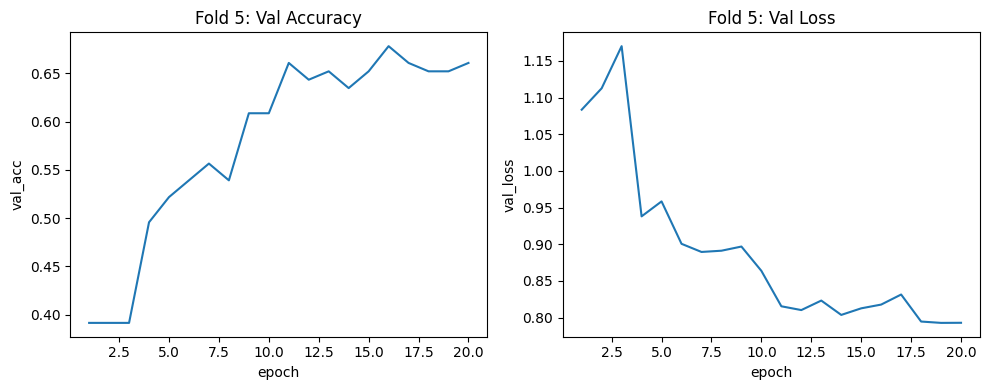


Fold best acc: [0.6724137931034483, 0.7413793103448276, 0.6782608695652174, 0.6956521739130435, 0.6782608695652174]
CV mean: 0.6931934032983509 std: 0.025320665544419696
CPU times: user 2min 34s, sys: 42.3 s, total: 3min 16s
Wall time: 4min 33s


In [43]:
%%time

FREEZE_EPOCHS = 2
PATIENCE = 7

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

for fold, (tr_idx, va_idx) in enumerate(skf.split(train_df_ms, train_df_ms["Category"])):
    df_tr = train_df_ms.iloc[tr_idx].reset_index(drop=True)
    df_va = train_df_ms.iloc[va_idx].reset_index(drop=True)

    tr_loader, va_loader = make_loaders(
        df_tr, df_va,
        batch_size=BATCH_SIZE,
        pixel_tf=pixel_minmax_tf,
        aug_tf_train=ms_train_tf,
        aug_tf_val=None,         
        check_shape=True
    )

    set_all_seeds(SEED + fold)    # To ensure determinism
    model = MSStemConvNeXt(backbone_name=BACKBONE, num_classes=NUM_CLASSES, drop=0.1).to(device)
    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    # freeze backbone initially
    for p in model.backbone.parameters():
        p.requires_grad = False

    # optimizer only for trainable params initially (stem+head)
    optimizer = torch.optim.AdamW(
        [
            {"params": model.stem.parameters(), "lr": lr_head},
            {"params": model.head.parameters(), "lr": lr_head},
        ],
        weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_acc = -1.0
    best_state = None
    bad_epochs = 0
    backbone_unfrozen = False

    print(f"\n===== FOLD {fold + 1} / {N_FOLDS} | train={len(df_tr)} valid={len(df_va)} =====")

    val_acc_hist = []
    val_loss_hist = []

    for epoch in range(1, EPOCHS + 1):

        # unfreeze backbone after FREEZE_EPOCHS
        if (not backbone_unfrozen) and (epoch == FREEZE_EPOCHS + 1):
            for p in model.backbone.parameters():
                p.requires_grad = True
            backbone_unfrozen = True

            # Rebuild optimizer to include backbone params
            optimizer = torch.optim.AdamW(
                [
                    {"params": model.backbone.parameters(), "lr": lr_backbone},
                    {"params": model.stem.parameters(), "lr": lr_head},
                    {"params": model.head.parameters(), "lr": lr_head},
                ],
                weight_decay=WEIGHT_DECAY
            )
            # Rebuild scheduler for remaining epochs
            remaining = EPOCHS - epoch + 1
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, remaining))

            print(f"Unfroze backbone at epoch {epoch}. Rebuilt optimizer/scheduler (remaining={remaining}).")

        tr_loss, tr_acc = train_one_epoch(model, tr_loader, optimizer, criterion, scaler)
        va_loss, va_acc = validate_one_epoch(model, va_loader, criterion)
        val_loss_hist.append(float(va_loss))
        val_acc_hist.append(float(va_acc))

        scheduler.step()

        improved = va_acc > best_acc
        if improved:
            best_acc = va_acc
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        current_lrs = [pg["lr"] for pg in optimizer.param_groups]
        lrs_str = "[" + ", ".join([f"{lr:.2e}" for lr in current_lrs]) + "]"
        
        if epoch in (1, 2, 3, 5, 10, 15, 20) or epoch % 5 == 0:
            print(f"Epoch {epoch:02d}/{EPOCHS} | "
                  f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
                  f"valid loss {va_loss:.4f} acc {va_acc:.4f} | "
                  f"best accuracy {best_acc:.4f} | "
                  f"patience {bad_epochs}/{PATIENCE}""\n"
                  f"lrs {lrs_str}")

        # early stopping
        if bad_epochs >= PATIENCE:
            print(f"Early stopping on epoch {epoch} (no val_acc improvement for {PATIENCE} epochs).")
            break

    # plots per fold (val metrics vs epoch index)
    epochs_ran = np.arange(1, len(val_acc_hist) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # Accuracy
    axes[0].plot(epochs_ran, val_acc_hist)
    axes[0].set_title(f"Fold {fold+1}: Val Accuracy")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("val_acc")
    
    # Loss
    axes[1].plot(epochs_ran, val_loss_hist)
    axes[1].set_title(f"Fold {fold+1}: Val Loss")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("val_loss")
    
    plt.tight_layout()
    plt.show()

    # Save best model of fold
    fold_states_ms.append(best_state)
    fold_best_acc.append(best_acc)

    # OOF logits from best model
    model.load_state_dict(best_state)
    fold_val_logits = predict_logits(model, va_loader)
    oof_logits_ms[va_idx] = fold_val_logits

print("\nFold best acc:", fold_best_acc)
print("CV mean:", float(np.mean(fold_best_acc)), "std:", float(np.std(fold_best_acc)))

In [46]:
oof_pred_ms = oof_logits_ms.argmax(axis=1)
oof_acc_ms = (oof_pred_ms == oof_true).mean()
print("OOF accuracy MS:", float(oof_acc_ms))

OOF accuracy MS: 0.6932409012131716


# RGB

In [13]:
rgb_train_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ToFloat(max_value=255.0),
    ToTensorV2(),
])

rgb_val_tf = A.Compose([
    A.ToFloat(max_value=255.0),
    ToTensorV2(),
])

In [14]:
class WheatRGBDataset(Dataset):
    def __init__(self, df, is_train: bool = True, aug_tf=None, check_shape: bool = False):
        df = df.reset_index(drop=True)
        self.is_train = is_train
        self.aug_tf = aug_tf
        self.check_shape = check_shape

        assert self.aug_tf is not None, "For RGB baseline, pass aug_tf with Normalize + ToTensorV2."

        self.rgb_paths = df["rgb_path"].astype(str).tolist()
        self.ids = df["Id"].astype(str).tolist()

        if is_train:
            self.y = df["Category"].map(cat2idx).to_numpy(np.int64)

    def __len__(self):
        return len(self.rgb_paths)

    def _read_rgb(self, path) -> np.ndarray:
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # HWC uint8
        return img

    def __getitem__(self, idx):
        img = self._read_rgb(self.rgb_paths[idx])

        if self.check_shape:
            if img.ndim != 3 or img.shape[2] != 3:
                raise ValueError(f"Unexpected RGB shape {img.shape} for {self.rgb_paths[idx]}")

        out = self.aug_tf(image=img)
        x = out["image"]  # torch.Tensor CHW float 
        if self.is_train:
            y = torch.tensor(self.y[idx], dtype=torch.long)
            return x, y, self.ids[idx]
        else:
            return x, self.ids[idx]

In [15]:
class RGBBackboneModel(nn.Module):
    def __init__(self, backbone_name="resnet18", num_classes=3, drop=0.2, pretrained=True):
        super().__init__()

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            num_classes=0,   
            global_pool="avg"   
        )

        feat_dim = self.backbone.num_features
        hidden = feat_dim // 2

        self.head = nn.Sequential(
            nn.Dropout(drop),
            nn.Linear(feat_dim, hidden),
            nn.ReLU(inplace=True),   
            nn.Dropout(drop),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        feats = self.backbone(x)
        return self.head(feats)

In [16]:
# configs
BATCH_SIZE = 32
NUM_CLASSES = len(CLASSES)
N_FOLDS = 5
EPOCHS = 30
lr_backbone = 1e-5
lr_head = 3e-4
WEIGHT_DECAY = 1e-2
BACKBONE = "resnet18"

use_amp = False    #torch.cuda.is_available()
pin = torch.cuda.is_available()

train_df_rgb = train_df.copy().reset_index(drop=True)

# OOF containers
oof_logits_rgb = np.zeros((len(train_df_rgb), NUM_CLASSES), dtype=np.float32)
oof_true   = train_df_rgb["Category"].map(cat2idx).values.astype(np.int64)

# Store model weights per fold
fold_states_rgb = []
fold_best_acc = []

In [17]:
def make_loaders(
    df_tr, df_va,
    batch_size=BATCH_SIZE,
    aug_tf_train=None,
    aug_tf_val=None,
    check_shape=False
    ):
    
    tr_ds = WheatRGBDataset(
        df_tr,
        is_train=True,
        aug_tf=aug_tf_train,
        check_shape=check_shape
        )
    va_ds = WheatRGBDataset(
        df_va,
        is_train=True,
        aug_tf=aug_tf_val,
        check_shape=check_shape
        )

    g = torch.Generator()
    g.manual_seed(SEED)

    tr_loader = DataLoader(
        tr_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=3,
        pin_memory=True,
        persistent_workers=False,
        prefetch_factor=2,
        generator=g,
        worker_init_fn=seed_worker
    )
    va_loader = DataLoader(
        va_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=3,
        pin_memory=True,
        persistent_workers=False,
        prefetch_factor=2,
        worker_init_fn=seed_worker,
        generator=g
    )
    return tr_loader, va_loader

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]


===== FOLD 1 / 5 | train=461 valid=116 =====
Epoch 01/30 | train loss 1.0933 acc 0.3644 | valid loss 1.0688 acc 0.4397 | best accuracy 0.4397 | patience 0/15
lrs [9.97e-06, 2.99e-04]
Epoch 02/30 | train loss 1.0535 acc 0.4577 | valid loss 1.0423 acc 0.4569 | best accuracy 0.4569 | patience 0/15
lrs [9.89e-06, 2.97e-04]
Epoch 03/30 | train loss 1.0115 acc 0.5510 | valid loss 1.0095 acc 0.5862 | best accuracy 0.5862 | patience 0/15
lrs [9.76e-06, 2.93e-04]
Epoch 05/30 | train loss 0.9878 acc 0.5315 | valid loss 0.9668 acc 0.5690 | best accuracy 0.5862 | patience 2/15
lrs [9.33e-06, 2.80e-04]
Epoch 10/30 | train loss 0.9209 acc 0.6139 | valid loss 0.9389 acc 0.4741 | best accuracy 0.5862 | patience 7/15
lrs [7.50e-06, 2.25e-04]
Epoch 15/30 | train loss 0.8566 acc 0.6421 | valid loss 0.9260 acc 0.4741 | best accuracy 0.5862 | patience 12/15
lrs [5.00e-06, 1.50e-04]
Early stopping on epoch 18 (no val_acc improvement for 15 epochs).


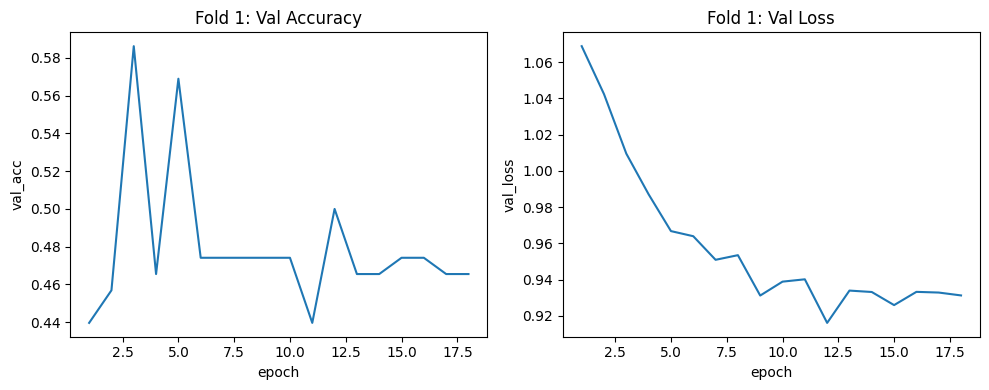


===== FOLD 2 / 5 | train=461 valid=116 =====
Epoch 01/30 | train loss 1.0869 acc 0.3818 | valid loss 1.0664 acc 0.4828 | best accuracy 0.4828 | patience 0/15
lrs [9.97e-06, 2.99e-04]
Epoch 02/30 | train loss 1.0377 acc 0.4729 | valid loss 1.0267 acc 0.5259 | best accuracy 0.5259 | patience 0/15
lrs [9.89e-06, 2.97e-04]
Epoch 03/30 | train loss 1.0063 acc 0.5293 | valid loss 0.9778 acc 0.5172 | best accuracy 0.5259 | patience 1/15
lrs [9.76e-06, 2.93e-04]
Epoch 05/30 | train loss 0.9692 acc 0.5401 | valid loss 0.9360 acc 0.5690 | best accuracy 0.5690 | patience 0/15
lrs [9.33e-06, 2.80e-04]
Epoch 10/30 | train loss 0.8844 acc 0.5987 | valid loss 0.9101 acc 0.5517 | best accuracy 0.5862 | patience 1/15
lrs [7.50e-06, 2.25e-04]
Epoch 15/30 | train loss 0.8720 acc 0.6247 | valid loss 0.8997 acc 0.5603 | best accuracy 0.6034 | patience 1/15
lrs [5.00e-06, 1.50e-04]
Epoch 20/30 | train loss 0.8856 acc 0.6052 | valid loss 0.9043 acc 0.5517 | best accuracy 0.6034 | patience 6/15
lrs [2.50e-06

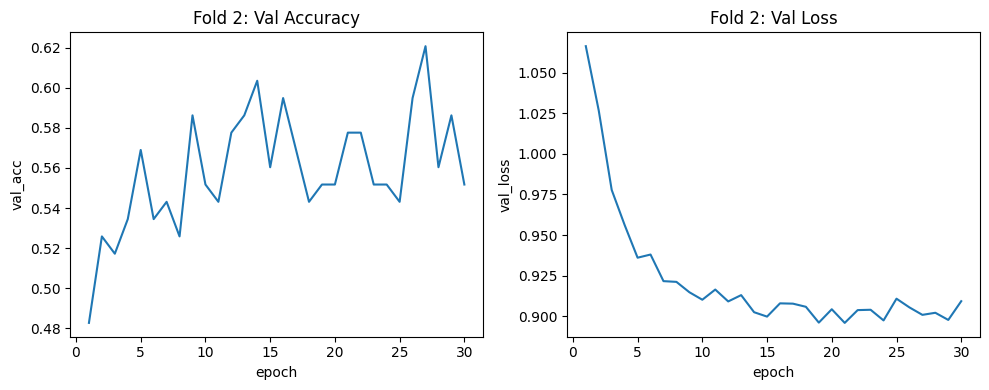


===== FOLD 3 / 5 | train=462 valid=115 =====
Epoch 01/30 | train loss 1.1002 acc 0.3528 | valid loss 1.0785 acc 0.4000 | best accuracy 0.4000 | patience 0/15
lrs [9.97e-06, 2.99e-04]
Epoch 02/30 | train loss 1.0533 acc 0.4416 | valid loss 1.0510 acc 0.4522 | best accuracy 0.4522 | patience 0/15
lrs [9.89e-06, 2.97e-04]
Epoch 03/30 | train loss 1.0047 acc 0.5498 | valid loss 1.0096 acc 0.4609 | best accuracy 0.4609 | patience 0/15
lrs [9.76e-06, 2.93e-04]
Epoch 05/30 | train loss 0.9657 acc 0.5563 | valid loss 0.9804 acc 0.5130 | best accuracy 0.5130 | patience 1/15
lrs [9.33e-06, 2.80e-04]
Epoch 10/30 | train loss 0.9080 acc 0.6061 | valid loss 0.9690 acc 0.5130 | best accuracy 0.5478 | patience 1/15
lrs [7.50e-06, 2.25e-04]
Epoch 15/30 | train loss 0.8700 acc 0.6061 | valid loss 0.9524 acc 0.5565 | best accuracy 0.5565 | patience 0/15
lrs [5.00e-06, 1.50e-04]
Epoch 20/30 | train loss 0.8703 acc 0.6039 | valid loss 0.9630 acc 0.5739 | best accuracy 0.5739 | patience 2/15
lrs [2.50e-06

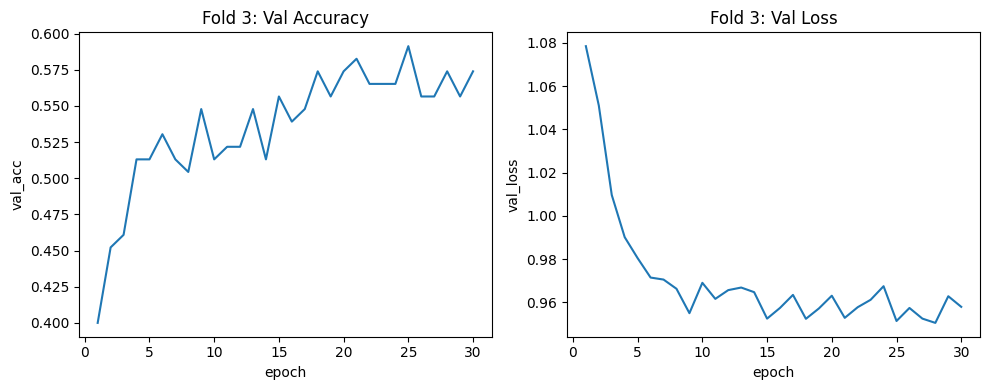


===== FOLD 4 / 5 | train=462 valid=115 =====
Epoch 01/30 | train loss 1.0875 acc 0.3853 | valid loss 1.0600 acc 0.4783 | best accuracy 0.4783 | patience 0/15
lrs [9.97e-06, 2.99e-04]
Epoch 02/30 | train loss 1.0421 acc 0.4740 | valid loss 1.0185 acc 0.5652 | best accuracy 0.5652 | patience 0/15
lrs [9.89e-06, 2.97e-04]
Epoch 03/30 | train loss 1.0054 acc 0.5216 | valid loss 0.9874 acc 0.5913 | best accuracy 0.5913 | patience 0/15
lrs [9.76e-06, 2.93e-04]
Epoch 05/30 | train loss 0.9562 acc 0.5606 | valid loss 0.9472 acc 0.6000 | best accuracy 0.6000 | patience 0/15
lrs [9.33e-06, 2.80e-04]
Epoch 10/30 | train loss 0.9121 acc 0.5844 | valid loss 0.9093 acc 0.5652 | best accuracy 0.6000 | patience 5/15
lrs [7.50e-06, 2.25e-04]
Epoch 15/30 | train loss 0.8746 acc 0.6169 | valid loss 0.9012 acc 0.5652 | best accuracy 0.6000 | patience 10/15
lrs [5.00e-06, 1.50e-04]
Epoch 20/30 | train loss 0.8806 acc 0.5974 | valid loss 0.9046 acc 0.5652 | best accuracy 0.6000 | patience 15/15
lrs [2.50e-

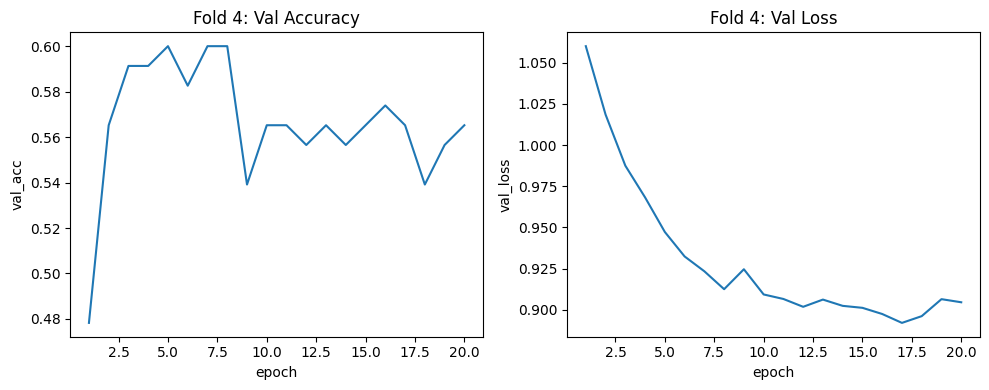


===== FOLD 5 / 5 | train=462 valid=115 =====
Epoch 01/30 | train loss 1.0841 acc 0.3983 | valid loss 1.0868 acc 0.4087 | best accuracy 0.4087 | patience 0/15
lrs [9.97e-06, 2.99e-04]
Epoch 02/30 | train loss 1.0280 acc 0.5195 | valid loss 1.0601 acc 0.4435 | best accuracy 0.4435 | patience 0/15
lrs [9.89e-06, 2.97e-04]
Epoch 03/30 | train loss 1.0081 acc 0.5455 | valid loss 1.0273 acc 0.5652 | best accuracy 0.5652 | patience 0/15
lrs [9.76e-06, 2.93e-04]
Epoch 05/30 | train loss 0.9512 acc 0.5541 | valid loss 1.0111 acc 0.5478 | best accuracy 0.5652 | patience 2/15
lrs [9.33e-06, 2.80e-04]
Epoch 10/30 | train loss 0.8771 acc 0.6147 | valid loss 0.9935 acc 0.5478 | best accuracy 0.5652 | patience 7/15
lrs [7.50e-06, 2.25e-04]
Epoch 15/30 | train loss 0.8606 acc 0.6320 | valid loss 1.0145 acc 0.5478 | best accuracy 0.5652 | patience 12/15
lrs [5.00e-06, 1.50e-04]
Early stopping on epoch 18 (no val_acc improvement for 15 epochs).


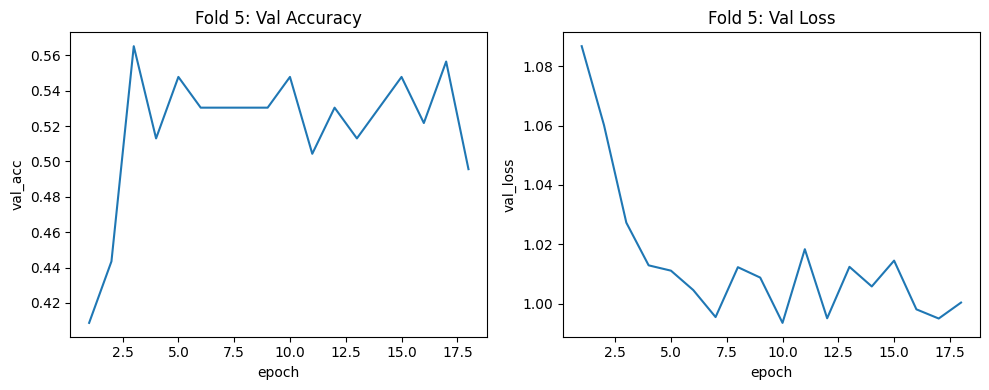


Fold best acc: [0.5862068965517241, 0.6206896551724138, 0.591304347826087, 0.6, 0.5652173913043478]
CV mean: 0.5926836581709145 std: 0.018089286771416066
CPU times: user 42.1 s, sys: 27.1 s, total: 1min 9s
Wall time: 2min 3s


In [18]:
%%time

PATIENCE = 15

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

for fold, (tr_idx, va_idx) in enumerate(
    skf.split(train_df_rgb, train_df_rgb["Category"])
):
    df_tr = train_df_rgb.iloc[tr_idx].reset_index(drop=True)
    df_va = train_df_rgb.iloc[va_idx].reset_index(drop=True)

    tr_loader, va_loader = make_loaders(
        df_tr, df_va,
        batch_size=BATCH_SIZE,
        aug_tf_train=rgb_train_tf,
        aug_tf_val=rgb_val_tf,
        check_shape=True
    )

    set_all_seeds(SEED + fold)    # To ensure determinism
    model = RGBBackboneModel(
        backbone_name=BACKBONE,
        num_classes=NUM_CLASSES,
        drop=0.2
    ).to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    optimizer = torch.optim.AdamW(
        [
            {"params": model.backbone.parameters(), "lr": lr_backbone},
            {"params": model.head.parameters(),     "lr": lr_head},
        ],
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS
    )

    best_acc = -1.0
    best_state = None
    bad_epochs = 0

    print(f"\n===== FOLD {fold + 1} / {N_FOLDS} | "
          f"train={len(df_tr)} valid={len(df_va)} =====")

    val_acc_hist = []
    val_loss_hist = []

    for epoch in range(1, EPOCHS + 1):

        tr_loss, tr_acc = train_one_epoch(
            model, tr_loader, optimizer, criterion, scaler
        )

        va_loss, va_acc = validate_one_epoch(
            model, va_loader, criterion
        )

        val_loss_hist.append(float(va_loss))
        val_acc_hist.append(float(va_acc))

        scheduler.step()

        if va_acc > best_acc:
            best_acc = va_acc
            best_state = {
                k: v.detach().cpu()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
        else:
            bad_epochs += 1

        current_lrs = [pg["lr"] for pg in optimizer.param_groups]
        lrs_str = "[" + ", ".join([f"{lr:.2e}" for lr in current_lrs]) + "]"

        if epoch in (1, 2, 3, 5, 10, 15, 20) or epoch % 5 == 0:
            print(
                f"Epoch {epoch:02d}/{EPOCHS} | "
                f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
                f"valid loss {va_loss:.4f} acc {va_acc:.4f} | "
                f"best accuracy {best_acc:.4f} | "
                f"patience {bad_epochs}/{PATIENCE}\n"
                f"lrs {lrs_str}"
            )

        if bad_epochs >= PATIENCE:
            print(
                f"Early stopping on epoch {epoch} "
                f"(no val_acc improvement for {PATIENCE} epochs)."
            )
            break

    epochs_ran = np.arange(1, len(val_acc_hist) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].plot(epochs_ran, val_acc_hist)
    axes[0].set_title(f"Fold {fold+1}: Val Accuracy")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("val_acc")

    axes[1].plot(epochs_ran, val_loss_hist)
    axes[1].set_title(f"Fold {fold+1}: Val Loss")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("val_loss")

    plt.tight_layout()
    plt.show()

    fold_states_rgb.append(best_state)
    fold_best_acc.append(best_acc)

    model.load_state_dict(best_state)
    fold_val_logits = predict_logits(model, va_loader)
    oof_logits_rgb[va_idx] = fold_val_logits


print("\nFold best acc:", fold_best_acc)
print("CV mean:", float(np.mean(fold_best_acc)),
      "std:", float(np.std(fold_best_acc)))

In [19]:
oof_pred_rgb = oof_logits_rgb.argmax(axis=1)
oof_acc_rgb = (oof_pred_rgb == oof_true).mean()
print("OOF accuracy RGB:", float(oof_acc_rgb))

OOF accuracy RGB: 0.5927209705372617


# HS

In [20]:
hs_train_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.MultiplicativeNoise(multiplier=(0.95, 1.05), per_channel=False, p=0.10),
 ], p=1.0)

hs_val_tf = A.Compose([], p=1.0)

In [21]:
def compute_hs_mean_std(
    hs_paths,
    drop_first=10,
    drop_last=14,
    keep_channels=125,
    hs_max=65535.0,
):

    channel_sum = None
    channel_sq_sum = None
    total_pixels = 0

    for path in tqdm(hs_paths):
        with rasterio.open(path) as src:
            x = src.read().astype(np.float32)  # (C,H,W)

        # 126 -> 125
        if x.shape[0] > keep_channels:
            x = x[:keep_channels]

        # trim noisy spectral ends
        x = x[drop_first: keep_channels - drop_last]  # (101,H,W)

        x = np.clip(x, 0.0, hs_max) / hs_max

        C, H, W = x.shape
        x = x.reshape(C, -1)  # (101, H*W)

        if channel_sum is None:
            channel_sum = x.sum(axis=1)
            channel_sq_sum = (x ** 2).sum(axis=1)
        else:
            channel_sum += x.sum(axis=1)
            channel_sq_sum += (x ** 2).sum(axis=1)

        total_pixels += H * W

    mean = channel_sum / total_pixels
    var = channel_sq_sum / total_pixels - mean ** 2
    std = np.sqrt(np.maximum(var, 1e-12))

    return mean.astype(np.float32), std.astype(np.float32)

In [22]:
def make_hs_standardize_tf(mean, std):

    mean = mean.reshape(-1, 1, 1)
    std = std.reshape(-1, 1, 1)

    def transform(x: np.ndarray) -> np.ndarray:
        return (x - mean) / (std + 1e-8)

    return transform

In [23]:
class WheatHSDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        is_train: bool = True,
        pixel_tf=None,
        aug_tf=None,
        check_shape: bool = False,
        drop_first: int = 10,
        drop_last: int = 14,
        keep_channels: int = 125,
    ):
        df = df.reset_index(drop=True)
        self.is_train = is_train
        self.pixel_tf = pixel_tf
        self.aug_tf = aug_tf
        self.check_shape = check_shape

        self.drop_first = drop_first
        self.drop_last = drop_last
        self.keep_channels = keep_channels

        self.hs_paths = df["hs_path"].astype(str).tolist()
        self.ids = df["Id"].astype(str).tolist()

        if is_train:
            self.y = df["Category"].map(cat2idx).to_numpy(np.int64)

    def __len__(self):
        return len(self.hs_paths)

    def _read_hs(self, path) -> np.ndarray:
        with rasterio.open(path) as src:
            x = src.read().astype(np.float32)  # (C,H,W)
        return x

    def _fix_and_trim(self, x: np.ndarray) -> np.ndarray:
        # fix 126 -> 125
        if x.shape[0] > self.keep_channels:
            x = x[:self.keep_channels]

        # optional strict shape check
        if self.check_shape:
            if x.shape[1:] != (32, 32):
                raise ValueError(f"Unexpected HS spatial shape {x.shape} for {path}")
            if x.shape[0] not in (self.keep_channels, self.keep_channels + 1):
                pass

        # drop noisy spectral ends
        if self.drop_last > 0:
            x = x[self.drop_first: self.keep_channels - self.drop_last]
        else:
            x = x[self.drop_first:]

        return x

    def __getitem__(self, idx):
        hs = self._read_hs(self.hs_paths[idx])  # (C,H,W)

        # fix channels + drop edges
        # (125 or 126) -> 125 -> 101
        if hs.shape[0] == 126:
            hs = hs[:125]
        hs = hs[10:125-14]  # 101 channels

        if self.check_shape and hs.shape[1:] != (32, 32):
            raise ValueError(f"Unexpected HS shape {hs.shape} for {self.hs_paths[idx]}")

        # Albumentations expects HWC
        if self.aug_tf is not None:
            hs_hwc = np.transpose(hs, (1, 2, 0))                 # (H,W,C)
            hs_hwc = self.aug_tf(image=hs_hwc)["image"]          # (H,W,C)
            hs = np.transpose(hs_hwc, (2, 0, 1)).astype(np.float32)  # (C,H,W)

        if self.pixel_tf is not None:
            hs = self.pixel_tf(hs)

        x = torch.from_numpy(hs)  # float32 CHW

        if self.is_train:
            y = torch.tensor(self.y[idx], dtype=torch.long)
            return x, y, self.ids[idx]
        else:
            return x, self.ids[idx]

In [24]:
def adapt_first_conv_in_chans(model: nn.Module, new_in_chans: int) -> nn.Module:
    """
    Replace the very first Conv2d in a timm model to accept `new_in_chans`.
    Init rule: take pretrained weights (out, 3, k, k) -> mean over input channels -> repeat to new_in_chans.
    Also scales by (old_in / new_in) to keep activation magnitude roughly comparable.
    """
    first_conv = None
    first_conv_name = None

    # find first Conv2d
    for name, m in model.named_modules():
        if isinstance(m, nn.Conv2d):
            first_conv = m
            first_conv_name = name
            break

    if first_conv is None:
        raise RuntimeError("No Conv2d found in model.")

    old_in = first_conv.in_channels
    if old_in == new_in_chans:
        return model

    if old_in != 3:
        print(f"[warn] First conv has in_channels={old_in}, not 3. Will still average from old_in.")

    # build new conv with same hyperparams
    new_conv = nn.Conv2d(
        in_channels=new_in_chans,
        out_channels=first_conv.out_channels,
        kernel_size=first_conv.kernel_size,
        stride=first_conv.stride,
        padding=first_conv.padding,
        dilation=first_conv.dilation,
        groups=first_conv.groups,   # convnext stem is usually groups=1
        bias=(first_conv.bias is not None),
        padding_mode=first_conv.padding_mode,
    )

    # init weights from pretrained
    with torch.no_grad():
        w = first_conv.weight  # (out, old_in, k, k)
        w_mean = w.mean(dim=1, keepdim=True)                 # (out, 1, k, k)
        w_new = w_mean.repeat(1, new_in_chans, 1, 1)         # (out, new_in, k, k)

        w_new *= (old_in / float(new_in_chans))

        new_conv.weight.copy_(w_new)

        if first_conv.bias is not None:
            new_conv.bias.copy_(first_conv.bias)

    # set it back into the model by name
    parent = model
    parts = first_conv_name.split(".")
    for p in parts[:-1]:
        parent = getattr(parent, p)
    setattr(parent, parts[-1], new_conv)

    return model


class HSStemConvNeXt(nn.Module):
    """
    HS input: (B, 101, 32, 32)
    Stem compresses 101 -> 16, then convnext_tiny adapted to in_chans=16.
    """
    def __init__(self, backbone_name="convnext_tiny", num_classes=3, drop=0.1, stem_width=64, out_chans=16):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(101, stem_width, kernel_size=1, bias=False),
            nn.BatchNorm2d(stem_width),
            nn.GELU(),
            nn.Conv2d(stem_width, out_chans, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_chans),
            nn.GELU(),
        )

        # create 3-ch pretrained backbone, then adapt first conv to 16 input chans
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)
        self.backbone = adapt_first_conv_in_chans(self.backbone, new_in_chans=out_chans)

        feat_dim = self.backbone.num_features
        hidden = feat_dim // 2

        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(drop),
            nn.Linear(feat_dim, hidden),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)          # (B, 16, H, W)
        feats = self.backbone(x)  # (B, feat_dim)
        return self.head(feats)

In [25]:
def make_loaders_hs(
    df_tr, df_va,
    batch_size=BATCH_SIZE,
    pixel_tf=None,
    aug_tf_train=None,
    aug_tf_val=None,
    check_shape=False
):
    tr_ds = WheatHSDataset(df_tr, is_train=True, pixel_tf=pixel_tf, aug_tf=aug_tf_train, check_shape=check_shape)
    va_ds = WheatHSDataset(df_va, is_train=True, pixel_tf=pixel_tf, aug_tf=aug_tf_val,   check_shape=check_shape)

    g = torch.Generator()
    g.manual_seed(SEED)

    tr_loader = DataLoader(
        tr_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=3,
        pin_memory=True,
        persistent_workers=False,
        prefetch_factor=2,
        generator=g,
        worker_init_fn=seed_worker
    )
    va_loader = DataLoader(
        va_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=3,
        pin_memory=True,
        persistent_workers=False,
        prefetch_factor=2,
        worker_init_fn=seed_worker,
        generator=g
    )
    return tr_loader, va_loader

In [31]:
# configs
BATCH_SIZE = 64
NUM_CLASSES = len(CLASSES)
N_FOLDS = 5
EPOCHS = 25
lr_backbone = 2e-5
lr_head = 1e-4
WEIGHT_DECAY = 5e-2
BACKBONE = "convnext_tiny"

use_amp = False    #torch.cuda.is_available()
pin = torch.cuda.is_available()

train_df_hs = train_df.copy().reset_index(drop=True)

# OOF containers
oof_logits_hs = np.zeros((len(train_df_hs), NUM_CLASSES), dtype=np.float32)
oof_true   = train_df_hs["Category"].map(cat2idx).values.astype(np.int64)

# Store model weights per fold
fold_states_hs = []
fold_best_acc = []

In [32]:
mean_hs, std_hs = compute_hs_mean_std(train_df_hs["hs_path"].tolist())
pixel_hsmax_tf = make_hs_standardize_tf(mean_hs, std_hs)

100%|██████████| 577/577 [00:05<00:00, 113.01it/s]



===== FOLD 1 / 5 | train=461 valid=116 =====
Epoch 01/25 | train loss 1.0576 acc 0.4100 | valid loss 0.9542 acc 0.5000 | best accuracy 0.5000 | patience 0/10
lrs [2.00e-05, 1.00e-04, 1.00e-04]
Epoch 02/25 | train loss 0.9249 acc 0.5597 | valid loss 0.8809 acc 0.5603 | best accuracy 0.5603 | patience 0/10
lrs [2.00e-05, 1.00e-04, 1.00e-04]
Epoch 03/25 | train loss 0.8547 acc 0.5835 | valid loss 0.8323 acc 0.5690 | best accuracy 0.5690 | patience 0/10
lrs [2.00e-05, 1.00e-04, 1.00e-04]
Epoch 05/25 | train loss 0.8000 acc 0.5944 | valid loss 0.7901 acc 0.6207 | best accuracy 0.6293 | patience 1/10
lrs [2.00e-05, 1.00e-04, 1.00e-04]
Epoch 10/25 | train loss 0.6845 acc 0.6833 | valid loss 0.7411 acc 0.6379 | best accuracy 0.6379 | patience 4/10
lrs [1.00e-05, 5.00e-05, 5.00e-05]
Epoch 15/25 | train loss 0.6250 acc 0.7332 | valid loss 0.7360 acc 0.6552 | best accuracy 0.6638 | patience 1/10
lrs [5.00e-06, 2.50e-05, 2.50e-05]
Epoch 20/25 | train loss 0.5469 acc 0.7744 | valid loss 0.7882 acc

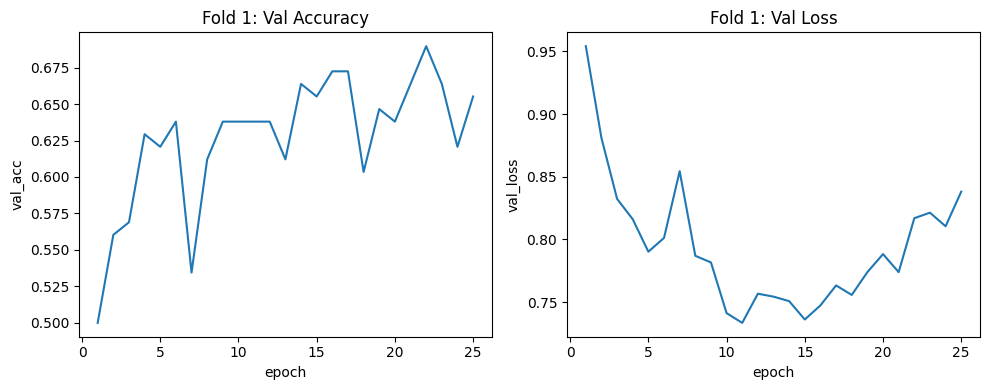


===== FOLD 2 / 5 | train=461 valid=116 =====
Epoch 01/25 | train loss 1.0455 acc 0.4252 | valid loss 0.9850 acc 0.4914 | best accuracy 0.4914 | patience 0/10
lrs [2.00e-05, 1.00e-04, 1.00e-04]
Epoch 02/25 | train loss 0.9078 acc 0.5770 | valid loss 0.7570 acc 0.6293 | best accuracy 0.6293 | patience 0/10
lrs [2.00e-05, 1.00e-04, 1.00e-04]
Epoch 03/25 | train loss 0.8439 acc 0.5857 | valid loss 0.8533 acc 0.5172 | best accuracy 0.6293 | patience 1/10
lrs [2.00e-05, 1.00e-04, 1.00e-04]
Epoch 05/25 | train loss 0.8423 acc 0.5857 | valid loss 0.7617 acc 0.6293 | best accuracy 0.6466 | patience 1/10
lrs [2.00e-05, 1.00e-04, 1.00e-04]
Epoch 10/25 | train loss 0.7368 acc 0.6573 | valid loss 0.7197 acc 0.6983 | best accuracy 0.7069 | patience 3/10
lrs [1.00e-05, 5.00e-05, 5.00e-05]
Epoch 15/25 | train loss 0.6465 acc 0.7115 | valid loss 0.7379 acc 0.7069 | best accuracy 0.7414 | patience 2/10
lrs [1.00e-05, 5.00e-05, 5.00e-05]
Epoch 20/25 | train loss 0.5990 acc 0.7397 | valid loss 0.6793 acc

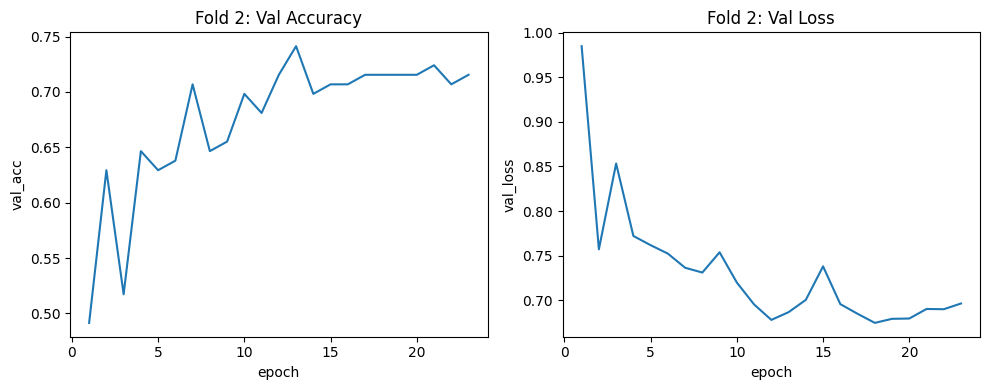


===== FOLD 3 / 5 | train=462 valid=115 =====
Epoch 01/25 | train loss 1.0586 acc 0.4351 | valid loss 0.9567 acc 0.5652 | best accuracy 0.5652 | patience 0/10
lrs [2.00e-05, 1.00e-04, 1.00e-04]
Epoch 02/25 | train loss 0.8912 acc 0.5714 | valid loss 0.8567 acc 0.6087 | best accuracy 0.6087 | patience 0/10
lrs [2.00e-05, 1.00e-04, 1.00e-04]
Epoch 03/25 | train loss 0.8765 acc 0.5541 | valid loss 0.8580 acc 0.5652 | best accuracy 0.6087 | patience 1/10
lrs [2.00e-05, 1.00e-04, 1.00e-04]
Epoch 05/25 | train loss 0.8232 acc 0.5866 | valid loss 0.7749 acc 0.6000 | best accuracy 0.6261 | patience 1/10
lrs [2.00e-05, 1.00e-04, 1.00e-04]
Epoch 10/25 | train loss 0.7530 acc 0.6429 | valid loss 0.8206 acc 0.6174 | best accuracy 0.6609 | patience 3/10
lrs [1.00e-05, 5.00e-05, 5.00e-05]
Epoch 15/25 | train loss 0.6430 acc 0.7013 | valid loss 0.7811 acc 0.6609 | best accuracy 0.6783 | patience 1/10
lrs [5.00e-06, 2.50e-05, 2.50e-05]
Epoch 20/25 | train loss 0.6016 acc 0.7186 | valid loss 0.7791 acc

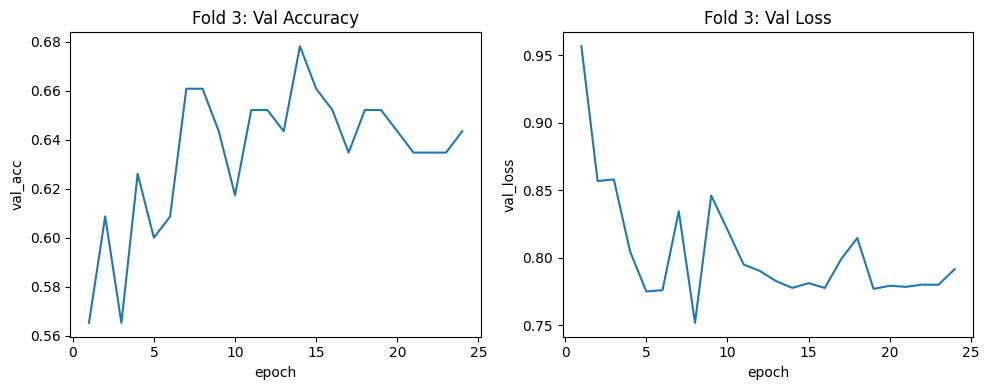


===== FOLD 4 / 5 | train=462 valid=115 =====
Epoch 01/25 | train loss 1.0144 acc 0.4589 | valid loss 0.8591 acc 0.5913 | best accuracy 0.5913 | patience 0/10
lrs [2.00e-05, 1.00e-04, 1.00e-04]
Epoch 02/25 | train loss 0.8495 acc 0.5823 | valid loss 0.7701 acc 0.6435 | best accuracy 0.6435 | patience 0/10
lrs [2.00e-05, 1.00e-04, 1.00e-04]
Epoch 03/25 | train loss 0.7971 acc 0.6104 | valid loss 0.7491 acc 0.6609 | best accuracy 0.6609 | patience 0/10
lrs [2.00e-05, 1.00e-04, 1.00e-04]
Epoch 05/25 | train loss 0.7810 acc 0.6061 | valid loss 0.7414 acc 0.6783 | best accuracy 0.6783 | patience 0/10
lrs [2.00e-05, 1.00e-04, 1.00e-04]
Epoch 10/25 | train loss 0.6717 acc 0.6926 | valid loss 0.6920 acc 0.6435 | best accuracy 0.7043 | patience 4/10
lrs [1.00e-05, 5.00e-05, 5.00e-05]
Epoch 15/25 | train loss 0.6282 acc 0.7078 | valid loss 0.7383 acc 0.6522 | best accuracy 0.7043 | patience 9/10
lrs [2.50e-06, 1.25e-05, 1.25e-05]
Early stopping on epoch 16 (no val_acc improvement for 10 epochs).

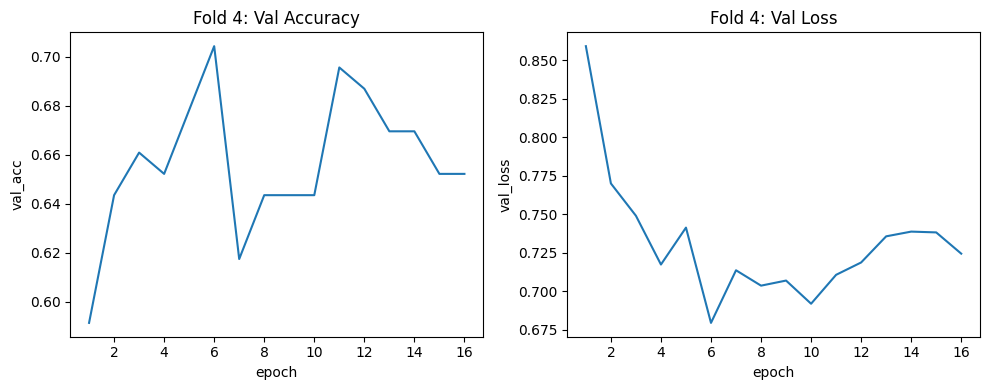


===== FOLD 5 / 5 | train=462 valid=115 =====
Epoch 01/25 | train loss 1.0563 acc 0.3831 | valid loss 0.9652 acc 0.5391 | best accuracy 0.5391 | patience 0/10
lrs [2.00e-05, 1.00e-04, 1.00e-04]
Epoch 02/25 | train loss 0.9070 acc 0.5563 | valid loss 0.8669 acc 0.6348 | best accuracy 0.6348 | patience 0/10
lrs [2.00e-05, 1.00e-04, 1.00e-04]
Epoch 03/25 | train loss 0.8334 acc 0.5952 | valid loss 0.8565 acc 0.6261 | best accuracy 0.6348 | patience 1/10
lrs [2.00e-05, 1.00e-04, 1.00e-04]
Epoch 05/25 | train loss 0.8089 acc 0.6212 | valid loss 0.8104 acc 0.6174 | best accuracy 0.6348 | patience 3/10
lrs [1.00e-05, 5.00e-05, 5.00e-05]
Epoch 10/25 | train loss 0.7315 acc 0.6472 | valid loss 0.8054 acc 0.6348 | best accuracy 0.6522 | patience 3/10
lrs [5.00e-06, 2.50e-05, 2.50e-05]
Epoch 15/25 | train loss 0.6290 acc 0.7078 | valid loss 0.7905 acc 0.6261 | best accuracy 0.6522 | patience 8/10
lrs [2.50e-06, 1.25e-05, 1.25e-05]
Epoch 20/25 | train loss 0.6150 acc 0.7013 | valid loss 0.8107 acc

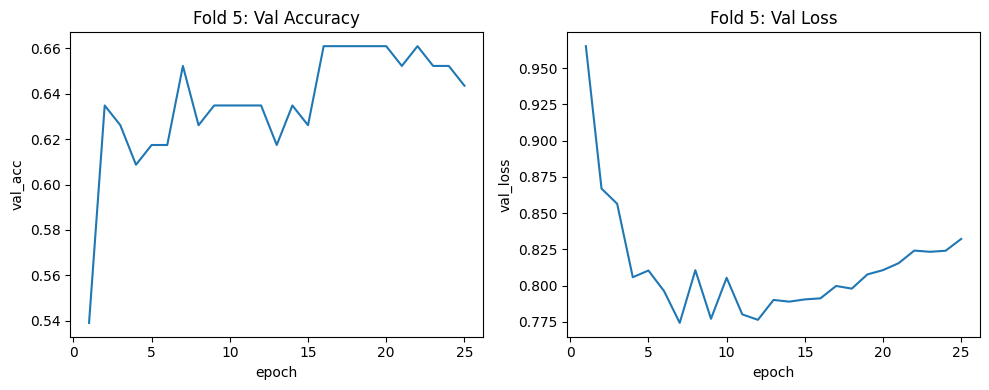


Fold best acc: [0.6896551724137931, 0.7413793103448276, 0.6782608695652174, 0.7043478260869566, 0.6608695652173913]
CV mean: 0.6949025487256371 std: 0.027247117443679424
CPU times: user 2min 26s, sys: 46.4 s, total: 3min 13s
Wall time: 7min 16s


In [33]:
%%time

PATIENCE = 10

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

for fold, (tr_idx, va_idx) in enumerate(skf.split(train_df_hs, train_df_hs["Category"])):
    df_tr = train_df_hs.iloc[tr_idx].reset_index(drop=True)
    df_va = train_df_hs.iloc[va_idx].reset_index(drop=True)
        
    tr_loader, va_loader = make_loaders_hs(
        df_tr, df_va,
        batch_size=BATCH_SIZE,
        pixel_tf=pixel_hsmax_tf,
        aug_tf_train=hs_train_tf,
        aug_tf_val=None,
        check_shape=True
    )

    set_all_seeds(SEED + fold)    # To ensure determinism
    model = HSStemConvNeXt(
        backbone_name=BACKBONE,
        num_classes=NUM_CLASSES,
        drop=0.1
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    optimizer = torch.optim.AdamW(
        [
            {"params": model.backbone.parameters(), "lr": lr_backbone},
            {"params": model.stem.parameters(),     "lr": lr_head},
            {"params": model.head.parameters(),     "lr": lr_head},
        ],
        weight_decay=WEIGHT_DECAY
    )

    # scheduler: reduce LR when val_acc plateaus
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",      
        factor=0.5,
        patience=2,
        threshold=1e-3,
        min_lr=1e-6
    )

    best_acc = -1.0
    best_state = None
    bad_epochs = 0

    print(f"\n===== FOLD {fold + 1} / {N_FOLDS} | train={len(df_tr)} valid={len(df_va)} =====")

    val_acc_hist = []
    val_loss_hist = []

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, tr_loader, optimizer, criterion, scaler)
        va_loss, va_acc = validate_one_epoch(model, va_loader, criterion)

        val_loss_hist.append(float(va_loss))
        val_acc_hist.append(float(va_acc))

        scheduler.step(va_acc)

        if va_acc > best_acc:
            best_acc = va_acc
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        current_lrs = [pg["lr"] for pg in optimizer.param_groups]
        lrs_str = "[" + ", ".join([f"{lr:.2e}" for lr in current_lrs]) + "]"

        if epoch in (1, 2, 3, 5, 10, 15, 20) or epoch % 5 == 0:
            print(f"Epoch {epoch:02d}/{EPOCHS} | "
                  f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
                  f"valid loss {va_loss:.4f} acc {va_acc:.4f} | "
                  f"best accuracy {best_acc:.4f} | "
                  f"patience {bad_epochs}/{PATIENCE}\n"
                  f"lrs {lrs_str}")

        if bad_epochs >= PATIENCE:
            print(f"Early stopping on epoch {epoch} (no val_acc improvement for {PATIENCE} epochs).")
            break

    # plots
    epochs_ran = np.arange(1, len(val_acc_hist) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(epochs_ran, val_acc_hist)
    axes[0].set_title(f"Fold {fold+1}: Val Accuracy")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("val_acc")

    axes[1].plot(epochs_ran, val_loss_hist)
    axes[1].set_title(f"Fold {fold+1}: Val Loss")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("val_loss")

    plt.tight_layout()
    plt.show()

    fold_states_hs.append(best_state)
    fold_best_acc.append(best_acc)

    model.load_state_dict(best_state)
    fold_val_logits = predict_logits(model, va_loader)
    oof_logits_hs[va_idx] = fold_val_logits

print("\nFold best acc:", fold_best_acc)
print("CV mean:", float(np.mean(fold_best_acc)), "std:", float(np.std(fold_best_acc)))

In [48]:
oof_pred_hs = oof_logits_hs.argmax(axis=1)
oof_acc_hs = (oof_pred_hs == oof_true).mean()
print("OOF accuracy HS:", float(oof_acc_hs))

OOF accuracy HS: 0.6949740034662045


In [ ]:
def find_best_blend_weights(oof_logits_ms, oof_logits_rgb, oof_logits_hs, y_true, grid_n=21):
    def acc_from_logits(logits, y):
        return (logits.argmax(axis=1) == y).mean()

    best_acc = -1.0
    best_w = None

    grid = np.linspace(0, 1, grid_n)
    for w_ms in grid:
        for w_rgb in grid:
            if w_ms + w_rgb > 1.0:
                continue
            w_hs = 1.0 - w_ms - w_rgb

            mix = w_ms * oof_logits_ms + w_rgb * oof_logits_rgb + w_hs * oof_logits_hs
            acc = acc_from_logits(mix, y_true)

            if acc > best_acc:
                best_acc = acc
                best_w = (float(w_ms), float(w_rgb), float(w_hs))

    return best_acc, best_w

In [ ]:
best_acc, best_w = find_best_blend_weights(oof_logits_ms, oof_logits_rgb, oof_logits_hs, oof_true, grid_n=21)
print("Best ensemble OOF acc:", best_acc)
print("Best weights (MS, RGB, HS):", best_w)

w_ms, w_rgb, w_hs = best_w

# Submission

In [76]:
@torch.no_grad()
def predict_logits_cv_states(model_ctor, states, test_loader):
    logits_sum = None

    for st in states:
        model = model_ctor().to(device)
        model.load_state_dict(st)
        model.eval()

        fold_logits = []
        for xb, ids in test_loader:
            xb = xb.to(device, non_blocking=True)
            logits = model(xb)
            fold_logits.append(logits.cpu().numpy())

        fold_logits = np.concatenate(fold_logits, axis=0)
        logits_sum = fold_logits if logits_sum is None else (logits_sum + fold_logits)

    return logits_sum / len(states)

In [77]:
def make_test_loader_ms(df_test, batch_size):
    ds = WheatMSDataset(df_test, is_train=False, pixel_tf=pixel_minmax_tf, aug_tf=None, check_shape=True)
    return DataLoader(ds, batch_size=batch_size, shuffle=False,
                      num_workers=3, pin_memory=True, persistent_workers=False,
                      prefetch_factor=2, worker_init_fn=seed_worker)

def make_test_loader_rgb(df_test, batch_size):
    ds = WheatRGBDataset(df_test, is_train=False, aug_tf=rgb_val_tf, check_shape=True)
    return DataLoader(ds, batch_size=batch_size, shuffle=False,
                      num_workers=3, pin_memory=True, persistent_workers=False,
                      prefetch_factor=2, worker_init_fn=seed_worker)

def make_test_loader_hs(df_test, batch_size):
    ds = WheatHSDataset(df_test, is_train=False, pixel_tf=pixel_hsmax_tf, aug_tf=None, check_shape=True)
    return DataLoader(
        ds, batch_size=batch_size, shuffle=False,
        num_workers=3, pin_memory=True, persistent_workers=False,
        prefetch_factor=2, worker_init_fn=seed_worker
    )

In [78]:
@torch.no_grad()
def predict_proba_ms_rgb_hs_ensemble(
    df_test,
    ms_states,
    rgb_states,
    hs_states,
    w_ms=0.6,
    w_rgb=0.0,
    w_hs=0.4,
    normalize_weights=True,
    batch_size_ms=64,
    batch_size_rgb=32,
    batch_size_hs=64,
):
    ms_loader  = make_test_loader_ms(df_test, batch_size_ms)
    rgb_loader = make_test_loader_rgb(df_test, batch_size_rgb)
    hs_loader  = make_test_loader_hs(df_test, batch_size_hs)

    def ms_ctor():
        return MSStemConvNeXt(
            backbone_name="convnext_tiny",
            num_classes=NUM_CLASSES,
            drop=0.1
        )

    def rgb_ctor():
        return RGBBackboneModel(
            backbone_name="resnet18",
            num_classes=NUM_CLASSES,
            drop=0.2
        )

    def hs_ctor():
        return HSStemConvNeXt(
            backbone_name="convnext_tiny",
            num_classes=NUM_CLASSES,
            drop=0.1  
        )

        # logits per modality
    logits_ms  = predict_logits_cv_states(ms_ctor,  ms_states,  ms_loader)
    logits_rgb = predict_logits_cv_states(rgb_ctor, rgb_states, rgb_loader)
    logits_hs  = predict_logits_cv_states(hs_ctor,  hs_states,  hs_loader)
    
    # blend logits 
    logits_mix = (
            w_ms * logits_ms +
            w_rgb * logits_rgb +
            w_hs * logits_hs
        )
    
    proba_mix = torch.softmax(torch.tensor(logits_mix), dim=1).numpy()
    
    pred_idx = proba_mix.argmax(axis=1)
    pred_cat = [idx2cat[i] for i in pred_idx]
    
    return proba_mix, pred_cat

In [79]:
test_proba, test_pred = predict_proba_ms_rgb_hs_ensemble(
    df_test=val_df,              
    ms_states=fold_states_ms,
    rgb_states=fold_states_rgb,
    hs_states=fold_states_hs,
    w_ms=w_ms, w_rgb=w_rgb, w_hs=w_hs,
    batch_size_ms=64,
    batch_size_rgb=32,
    batch_size_hs=64
)

In [80]:
# calculation of dummy variables for a hidden test
def find_constant_triplet_ids(df: pd.DataFrame, eps: float = 1e-6) -> set[str]:
    def is_const(path: str) -> bool:
        with rasterio.open(path) as src:
            x = src.read().astype(np.float32)
        return float(x.std()) < eps

    ids = set()
    for _, row in df.iterrows():
        if is_const(row["rgb_path"]) and is_const(row["ms_path"]) and is_const(row["hs_path"]):
            ids.add(str(row["Id"]))
    return ids

empty_ids = find_constant_triplet_ids(val_df, eps=1e-6)

In [81]:
submission = pd.DataFrame({
    "Id": val_df["Id"].values,
    "Category": test_pred
})
submission.loc[submission["Id"].isin(empty_ids), "Category"] = "Other"
submission["Id"] = submission["Id"].astype(str) + ".tif"
submission.to_csv("submission.csv", index=False)

submission.head()

,Id,Category
0,val_000a83c1.tif,Health
1,val_00a704b1.tif,Other
2,val_01dde030.tif,Other
3,val_024df365.tif,Rust
4,val_02afcb0e.tif,Rust
